Here, we assess whether a univariate TF analysis (differential TF activity) is consistent between the predicted and actual data. To measure the reproducibility of DE, we use the CATplot from [svaseq](https://doi.org/10.1093/nar/gku864). We use the Jaccard Index as our metric of concordance, and we separately assess positively and negatively differentially expressed genes.

For concordance, we filter TFs with an FDR>0.1. If we set a cliffs delta filter (for "negligible"), we rank order by the effect size. Otherwsie, we rank order by significance. We calculate the concordance across all TFs that pass this threshold, to the rank of the result with fewer total TFs that passed the threshold. 

In [1]:
import os
from typing import Literal, List

from tqdm import tqdm

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from scipy import stats
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

sys.path.insert(1, '../.')
from Kang_utils import get_prediction, rev_stim

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [7]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

# test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
# test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
# train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

test_cells = trainer.X_test.index.tolist()
train_cells_all = trainer.X_train.index.tolist()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())




[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

#### Get the predictions and concordance:

As described in Notebook 06E, for each cell type, we get the counterfactual from all in-distribution or within a cell type ("opposite").

The statistical power of DE can increase with more samples. So, given a counterfactual that generates more predictions than the actual dataset, this can decrease our concordance values. Within a given condition, in instances where the number of predicted cells != number of actual cells, we randomly subset the larger dataset to equal that of the smaller one. For the in-distribution counterfactual, we expect the actual data to be smaller than the predicted, and for the opposite we may get a mix.
    

In [40]:
def prepare_for_metrics(tf_adata_predicted, 
                        tf_adata, 
                       test_conds, 
                       rev_stim):
    ctrl_conds = ['^'.join([rev_stim[i.split('^')[0]], i.split('^')[1]]) for i in test_conds]
    tf_adata_actual = tf_adata[tf_adata.obs.condition.isin(test_conds), :].copy()
    tf_adata_ctrl = tf_adata[tf_adata.obs.condition.isin(ctrl_conds), :].copy()

    # subset so that the test condition is equal between the predicted and actual data
    cells_predicted_all = []
    cells_actual_all = []
    for cond, n_cells_predicted in tf_adata_predicted.obs.condition.value_counts().to_dict().items():
        cells_predicted = tf_adata_predicted.obs[tf_adata_predicted.obs.condition == cond].index.tolist()

        cells_actual = tf_adata_actual.obs[tf_adata_actual.obs.condition == cond].index.tolist()
        n_cells_actual = len(cells_actual)

        if n_cells_actual > n_cells_predicted:
            cells_predicted_all += cells_predicted
            np.random.seed(seed)
            cells_actual_all += list(np.random.choice(a = cells_actual, size = n_cells_predicted,
                                                      replace = False))

        elif n_cells_actual < n_cells_predicted:
            cells_actual_all += cells_actual
            np.random.seed(seed)
            cells_predicted_all += list(np.random.choice(a = cells_predicted, size = n_cells_actual,
                                                           replace = False))
        else:
            cells_predicted_all += cells_predicted
            cells_actual_all += cells_actual
    tf_adata_actual = tf_adata_actual[cells_actual_all,:]
    tf_adata_predicted = tf_adata_predicted[cells_predicted_all,:]
    
    return tf_adata_predicted, tf_adata_actual, tf_adata_ctrl

from typing import Literal
def TF_de(df_A, 
          df_B, 
          fdr_thresh = 0.1, 
          effect_size_thresh: Literal['negligible', 'small', 'medium', 'large'] = 'small', 
         rank_by: Literal['fdr', 'effect_size'] = 'effect_size'):
    """Conduct the DE between two DFs. 

    Parameters
    ----------
    df_A : _type_
        _description_
    df_B : _type_
        _description_
    fdr_thresh : float, optional
        only retain DE TFs with FDRs less than or equal to this threshold, by default 0.1
        if None, will not threshold on FDR
    effect_size_thresh : Literal['negligible', 'small', 'medium', 'large'], optional
        only retain effect sizes greater than or equal to this category, by default 'small'
        effect size is measured with Cliff's Delta, which heuristically categorizes values in one of these four categories
    rank_by :  Literal['fdr', 'effect_size'], optional
        rank order TFs by false discovery rate (fdr) or effect size (effect_size), by default 'effect_size'
    """
    if fdr_thresh is None:
        fdr_thresh = 1
    pvals = stats.mannwhitneyu(df_A, df_B, alternative = 'two-sided', axis = 0).pvalue
#     _, pvals = stats.ttest_ind(df_A, df_B, alternative = 'two-sided', equal_var=False, axis = 0)
    _, fdrs, _, _ = multipletests(pvals, method='fdr_bh')

    cd = pd.DataFrame(columns = ['effect_size', 'effect'])
    for feature in df_A.columns:
        cd_val = cliffs_delta(df_A[feature], df_B[feature])
        cd.loc[feature, :] = cd_val
    cd['effect'] = pd.Categorical(cd.effect, ordered = True, 
                                        categories = ['negligible', 'small', 'medium', 'large'])
    cd['fdr'] = fdrs
    de = cd[cd['fdr'] <= fdr_thresh] 
    if effect_size_thresh is not None:
        de = de[de['effect'] >= effect_size_thresh]
    
    if rank_by == 'effect_size':
        de = de.sort_values(by='effect_size', key=abs, ascending = False)
    elif rank_by == 'fdr':
        de = de.sort_values(by = 'fdr', ascending = True)
    else:
        raise ValueError('Incorrect rank_by parameter specified')

    de_pos = de[de.effect_size >= 0]
    de_neg = de[de.effect_size < 0]
    
    return de_pos, de_neg, de

def jaccard_index(list1, list2):
    set1, set2 = set(list1), set(list2)
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    return len(intersection) / len(union) if len(union) != 0 else 0
def get_concordance(df1, df2, col_name = 'jaccard_index'):
    cat = pd.DataFrame(columns = [col_name])
    max_rank = min(df1.shape[0], df2.shape[0])
    list1 = df1.index.tolist()
    list2 = df2.index.tolist()
    
    for r in range(1, max_rank + 1):
        cat.loc[r, :] = jaccard_index(list1[:r], list2[:r])
    return cat
    
def get_concordance_all(tf_adata_predicted, tf_adata_actual, tf_adata_ctrl, 
                       test_cond, ctrl_cond, 
                        fdr_thresh = 0.1, effect_size_thresh = 'small'):

    predicted_df = tf_adata_predicted[tf_adata_predicted.obs.condition == test_cond].to_df()
    actual_df = tf_adata_actual[tf_adata_actual.obs.condition == test_cond].to_df()
    ctrl_df = tf_adata_ctrl[tf_adata_ctrl.obs.condition == ctrl_cond].to_df()
    
    de_actual_pos, de_actual_neg, de_actual_all = TF_de(ctrl_df, actual_df, 
                                                        fdr_thresh = fdr_thresh, 
                                                        effect_size_thresh = effect_size_thresh)
    de_predicted_pos, de_predicted_neg, de_predicted_all = TF_de(ctrl_df, predicted_df, 
                                                                 fdr_thresh = fdr_thresh,
                                                                 effect_size_thresh = effect_size_thresh)

    cat_pos = get_concordance(de_actual_pos, de_predicted_pos, col_name = 'Positive')
    cat_neg = get_concordance(de_actual_neg, de_predicted_neg, col_name = 'Negative')
    cat_df = pd.concat([cat_pos, cat_neg], axis = 1, join='outer')
    cat_df['rank'] = cat_df.index.tolist()
    cat_df = cat_df.melt(id_vars='rank', value_name='jaccard_index', var_name='effect_direction')
    
    return cat_df, de_actual_all, de_predicted_all

In [14]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

In [34]:
effect_size_thresh = 'small'
fdr_thresh = 0.1 
rank_by = 'effect_size'

In [20]:
cat_df_all = pd.DataFrame(columns = ['rank', 'effect_direction', 'jaccard_index', 
                                     'cell_type', 'counterfactual_type'])
for counterfactual_type in tqdm(counterfactual_types):
    tf_adata_predicted = get_prediction(mod = mod, 
                                        tf_adata = tf_adata, 
                                        counterfactual_type = counterfactual_type, 
                                        cf_map = cf_map, 
                                        train_cells_all = train_cells_all, 
                                        test_conds = test_conds
                                        )
    
    res = prepare_for_metrics(tf_adata_predicted = tf_adata_predicted, 
                              tf_adata = tf_adata, 
                              test_conds = test_conds, 
                              rev_stim = rev_stim)
    tf_adata_predicted, tf_adata_actual, tf_adata_ctrl = res
    
    # concordance per cell type
    cat_df_conds = pd.DataFrame(columns = ['rank', 'effect_direction', 'jaccard_index', 'cell_type'])
    for test_cond in test_conds:
        ctrl_cond = '^'.join([rev_stim[test_cond.split('^')[0]], test_cond.split('^')[1]])
        cat_df, _, _ = get_concordance_all(tf_adata_predicted, tf_adata_actual, tf_adata_ctrl, 
                                     test_cond, ctrl_cond, 
                                     fdr_thresh = fdr_thresh, effect_size_thresh = effect_size_thresh)
        cat_df['cell_type'] = test_cond.split('^')[1]
        cat_df_conds = pd.concat([cat_df_conds, cat_df], ignore_index = True, axis = 0)
    cat_df_conds['counterfactual_type'] = counterfactual_type
    cat_df_all = pd.concat([cat_df_all, cat_df_conds], ignore_index = True, axis = 0)


  0%|                                                       | 0/2 [00:00<?, ?it/s]/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
 50%|███████████████████████▌                       | 1/2 [00:23<00:23, 23.82s/it]/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
100%|███████████████████████████████████████████████| 2/2 [00:31<00:00, 15.87s/it]


#### Visualize

In [21]:
cat_df_all.counterfactual_type = cat_df_all.counterfactual_type.map({'in_distribution': 'In Disribution', 'opposite': 'Opposite'})



/tmp/ipykernel_3574551/517454330.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.9])


''

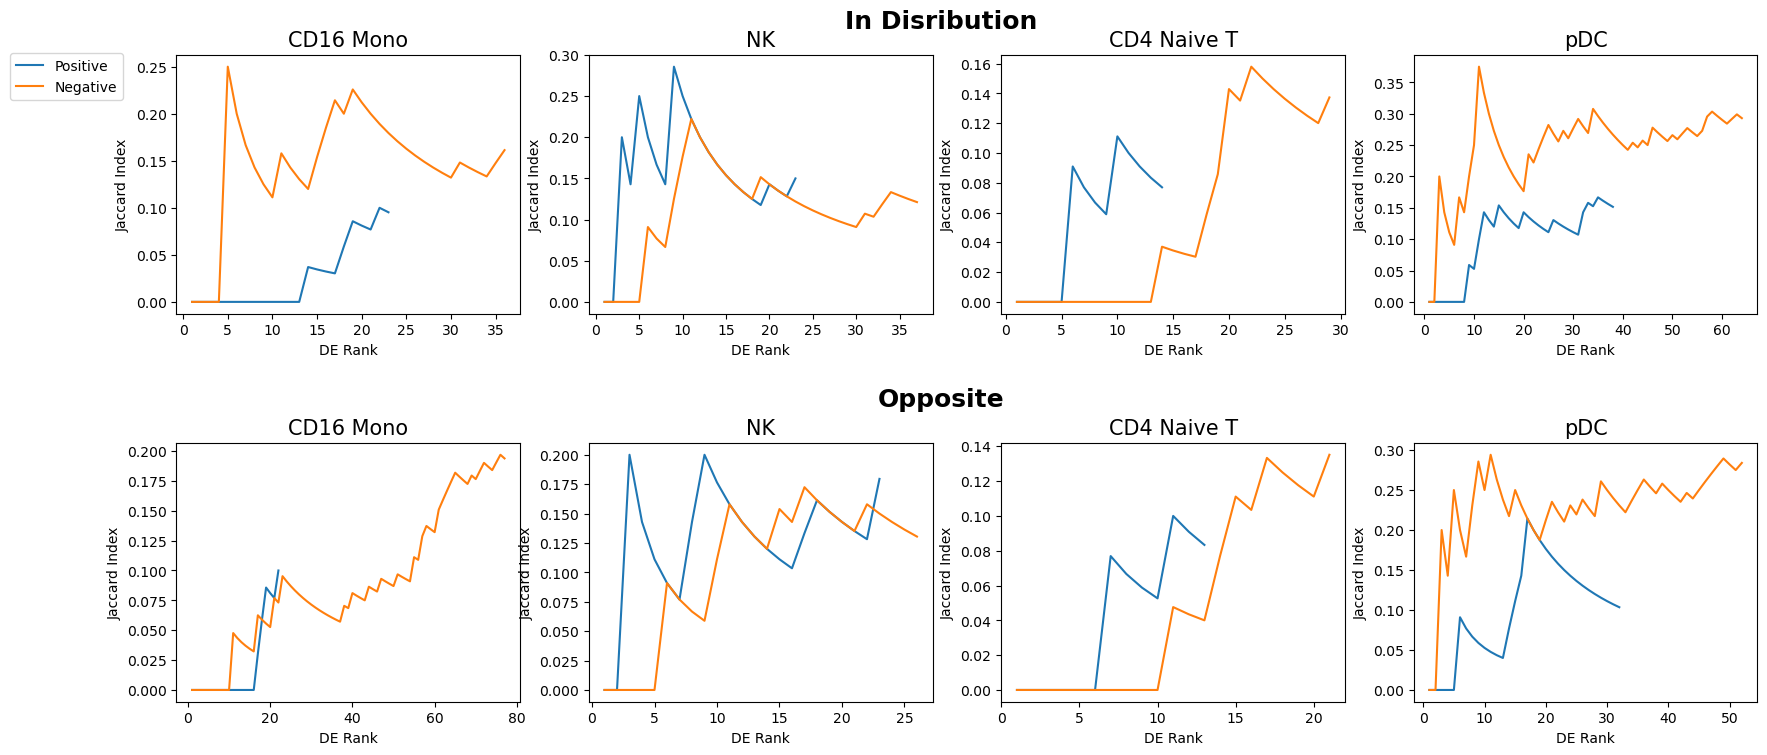

In [22]:
ncols = cat_df_all.cell_type.nunique()
nrows = cat_df_all.counterfactual_type.nunique()
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 4.2*nrows), 
                      gridspec_kw={'hspace': 0.5})
# ax = axes.flatten()
title_coords = [0.92, 0.47]
for (i, counterfactual_type) in enumerate(cat_df_all.counterfactual_type.unique()):
    cat_df = cat_df_all[cat_df_all.counterfactual_type == counterfactual_type]
    for (j, cell_type) in enumerate(cat_df_all.cell_type.unique()):
        viz_df = cat_df[cat_df.cell_type == cell_type]
        
        sns.lineplot(data = viz_df, y = 'jaccard_index', x = 'rank', hue = 'effect_direction', 
                    ax = ax[i, j])
        ax[i,j].set_ylabel('Jaccard Index')
        ax[i,j].set_xlabel('DE Rank')
        ax[i,j].set_title(cell_type, fontsize = 15)
        
        if [i,j] == [0,0]:
            handles, labels = ax[i,j].get_legend_handles_labels()
        ax[i,j].legend().remove()

        
    fig.text(0.5, title_coords[i], counterfactual_type, ha='center', va='center', fontsize=18, fontweight='bold')

# Adjust layout
fig.tight_layout(rect=[0, 0, 1, 0.9])
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.04, 0.89))
;

Concordance doesn't look great, but between Jaccard index and specifics of FDR correction, it is a pretty stringent metric. Let's instead look at the Spearman correlation of effect sizes across all TFs for each condition:

In [136]:
# everything is kept
fdr_thresh = None
effect_size_thresh = 'negligible'
rank_by = 'effect_size'

In [141]:
corr_df_all = pd.DataFrame(columns = ['correlation', 'n_cells', 'cell_type', 'counterfactual_type'])
for counterfactual_type in tqdm(counterfactual_types):
    tf_adata_predicted = get_prediction(mod = mod, 
                                        tf_adata = tf_adata, 
                                        counterfactual_type = counterfactual_type, 
                                        cf_map = cf_map, 
                                        train_cells_all = train_cells_all, 
                                        test_conds = test_conds
                                        )
    
    res = prepare_for_metrics(tf_adata_predicted = tf_adata_predicted, 
                              tf_adata = tf_adata, 
                              test_conds = test_conds, 
                              rev_stim = rev_stim)
    tf_adata_predicted, tf_adata_actual, tf_adata_ctrl = res
    
    corr_df_conds = pd.DataFrame(columns = ['correlation', 'n_cells', 'cell_type'])
    for test_cond in test_conds:
        ctrl_cond = '^'.join([rev_stim[test_cond.split('^')[0]], test_cond.split('^')[1]])
        _, de_actual_all, de_predicted_all = get_concordance_all(tf_adata_predicted, tf_adata_actual, tf_adata_ctrl, 
                                     test_cond, ctrl_cond, 
                                     fdr_thresh = fdr_thresh, effect_size_thresh = effect_size_thresh)
        
        effect_size_actual = de_predicted_all.effect_size
        effect_size_predicted = de_actual_all.effect_size
        sr = stats.spearmanr(effect_size_predicted.loc[effect_size_actual.index], effect_size_actual).statistic
        
        cell_type = test_cond.split('^')[1]
        n_train_cells = tf_adata_ctrl.obs.seurat_annotations.value_counts().loc[cell_type]
        if n_train_cells != tf_adata.obs[(tf_adata.obs.seurat_annotations == cell_type) & (tf_adata.obs.condition != test_cond)].shape[0]:
            raise ValueError('Unexpected difference in actual and control data')
        corr_df_conds.loc[corr_df_conds.shape[0], :] = [sr, n_train_cells, cell_type]
    corr_df_conds['counterfactual_type'] = counterfactual_type
    corr_df_all = pd.concat([corr_df_all, corr_df_conds], ignore_index = True, axis = 0)


  0%|                                                       | 0/2 [00:00<?, ?it/s]/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
 50%|███████████████████████▌                       | 1/2 [00:23<00:23, 23.92s/it]/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
100%|███████████████████████████████████████████████| 2/2 [00:32<00:00, 16.16s/it]


In [142]:
corr_df_all.counterfactual_type = corr_df_all.counterfactual_type.map({'in_distribution': 'In Disribution', 'opposite': 'Opposite'})


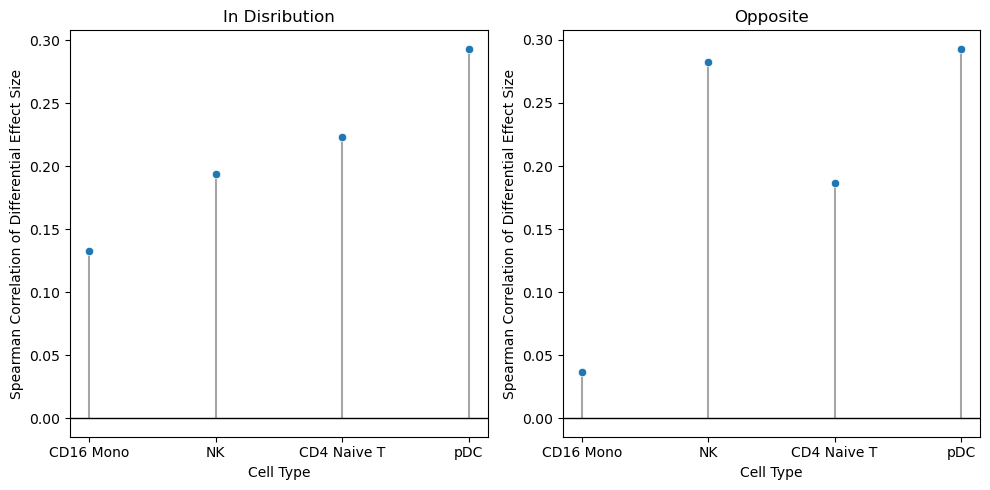

In [143]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))


for i, counterfactual_type in enumerate(corr_df_all.counterfactual_type.unique()):
    viz_df = corr_df_all[corr_df_all.counterfactual_type == counterfactual_type]
    sns.scatterplot(data = viz_df, y = 'correlation', x = 'cell_type', ax = ax[i])
    ax[i].set_xlabel('Cell Type')
    ax[i].set_ylabel('Spearman Correlation of Differential Effect Size')
    ax[i].set_title(counterfactual_type)

    ax[i].axhline(0, color='black', linewidth=1)
    ax[i].vlines(x=viz_df.cell_type, ymin=0, ymax=viz_df.correlation, color='gray', alpha=0.7, zorder=0)
fig.tight_layout()

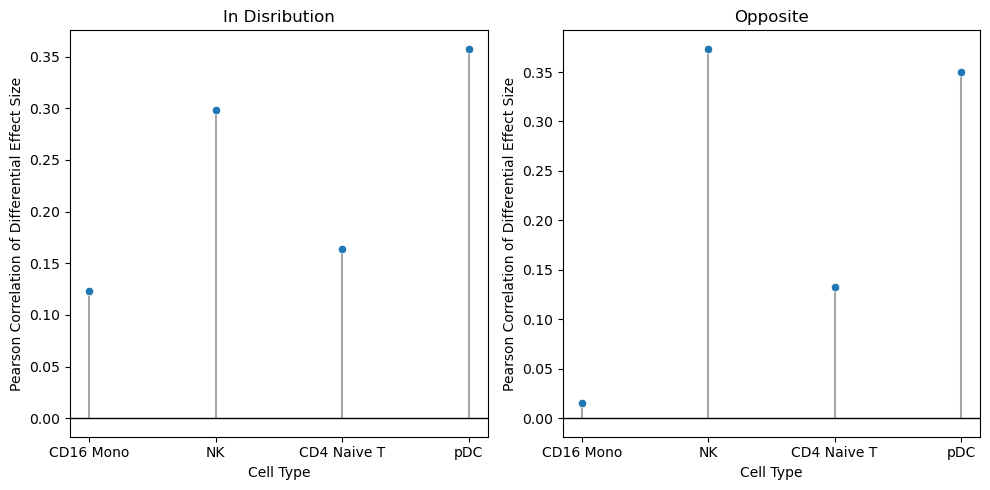

In [140]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))


for i, counterfactual_type in enumerate(corr_df_all.counterfactual_type.unique()):
    viz_df = corr_df_all[corr_df_all.counterfactual_type == counterfactual_type]
    sns.scatterplot(data = viz_df, y = 'correlation', x = 'cell_type', ax = ax[i])
    ax[i].set_xlabel('Cell Type')
    ax[i].set_ylabel('Pearson Correlation of Differential Effect Size')
    ax[i].set_title(counterfactual_type)

    ax[i].axhline(0, color='black', linewidth=1)
    ax[i].vlines(x=viz_df.cell_type, ymin=0, ymax=viz_df.correlation, color='gray', alpha=0.7, zorder=0)
fig.tight_layout()